STEP 1: LOADING DATA
Data loaded: (4424, 37)

STEP 2: SEPARATING FEATURES AND TARGET
Features shape: (4424, 36)
Target shape: (4424,)
Target classes: ['Dropout' 'Graduate' 'Enrolled']

STEP 3: ENCODING TARGET VARIABLE
Encoded classes: ['Dropout' 'Enrolled' 'Graduate']
Mapping: Dropout=0, Enrolled=1, Graduate=2

STEP 4: TRAIN-TEST SPLIT (80/20)
Training set: (3539, 36)
Testing set: (885, 36)

STEP 5: FEATURE SCALING (StandardScaler)
Scaling completed!

STEP 6: CREATING 4 MODELS
Models created:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - KNN

STEP 7: TRAINING AND EVALUATING MODELS

Training Logistic Regression...
  Accuracy: 0.7684
  F1-Score: 0.7531

Training Decision Tree...
  Accuracy: 0.6972
  F1-Score: 0.6994

Training Random Forest...
  Accuracy: 0.7672
  F1-Score: 0.7539

Training KNN...
  Accuracy: 0.6678
  F1-Score: 0.6553

STEP 8: MODEL COMPARISON RESULTS
              Model  Accuracy  Precision   Recall  F1-Score
      Random Forest  0.767232   0.754445 0.7

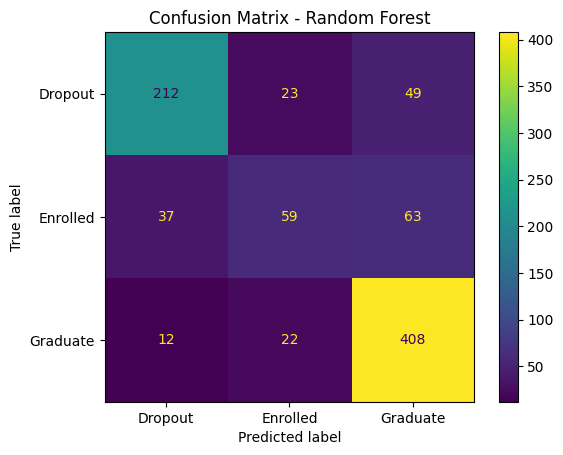


STEP 12: SAVING MODELS
Files saved in 'models' folder:
  - best_model.pkl
  - scaler.pkl
  - label_encoder.pkl
  - model_comparison_results.csv

MODEL DEVELOPMENT COMPLETE!


In [1]:
# NOTEBOOK 2: MODEL DEVELOPMENT
# Student Performance Prediction - Training & Evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# 1. LOAD PREPROCESSED DATA
print("=" * 50)
print("STEP 1: LOADING DATA")
print("=" * 50)

df = pd.read_csv("data.csv", sep=';')
print(f"Data loaded: {df.shape}")

# 2. SEPARATE FEATURES AND TARGET
print("\n" + "=" * 50)
print("STEP 2: SEPARATING FEATURES AND TARGET")
print("=" * 50)

X = df.drop("Target", axis=1)
y = df["Target"]
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target classes: {y.unique()}")

# 3. ENCODE TARGET VARIABLE
print("\n" + "=" * 50)
print("STEP 3: ENCODING TARGET VARIABLE")
print("=" * 50)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"Encoded classes: {label_encoder.classes_}")
print(f"Mapping: Dropout=0, Enrolled=1, Graduate=2")

# 4. TRAIN-TEST SPLIT
print("\n" + "=" * 50)
print("STEP 4: TRAIN-TEST SPLIT (80/20)")
print("=" * 50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

# 5. FEATURE SCALING
print("\n" + "=" * 50)
print("STEP 5: FEATURE SCALING (StandardScaler)")
print("=" * 50)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling completed!")

# 6. CREATE MODELS
print("\n" + "=" * 50)
print("STEP 6: CREATING 4 MODELS")
print("=" * 50)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}
print("Models created:")
for name in models.keys():
    print(f"  - {name}")

# 7. TRAIN AND EVALUATE MODELS
print("\n" + "=" * 50)
print("STEP 7: TRAINING AND EVALUATING MODELS")
print("=" * 50)

results = []
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Train with scaled or unscaled data
    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

    trained_models[name] = model
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1-Score: {f1:.4f}")

# 8. DISPLAY RESULTS TABLE
print("\n" + "=" * 50)
print("STEP 8: MODEL COMPARISON RESULTS")
print("=" * 50)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-Score", ascending=False)
print(results_df.to_string(index=False))

# 9. SELECT BEST MODEL
print("\n" + "=" * 50)
print("STEP 9: SELECTING BEST MODEL")
print("=" * 50)

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print(f"Best Model: {best_model_name}")

# 10. DETAILED CLASSIFICATION REPORT FOR BEST MODEL
print("\n" + "=" * 50)
print("STEP 10: DETAILED CLASSIFICATION REPORT")
print("=" * 50)

if best_model_name in ["Logistic Regression", "KNN"]:
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

print(classification_report(y_test, y_pred_best, target_names=label_encoder.classes_))

# 11. CONFUSION MATRIX
print("\n" + "=" * 50)
print("STEP 11: CONFUSION MATRIX")
print("=" * 50)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

# 12. SAVE MODELS
print("\n" + "=" * 50)
print("STEP 12: SAVING MODELS")
print("=" * 50)

os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/best_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(label_encoder, "models/label_encoder.pkl")
results_df.to_csv("models/model_comparison_results.csv", index=False)

print("Files saved in 'models' folder:")
print("  - best_model.pkl")
print("  - scaler.pkl")
print("  - label_encoder.pkl")
print("  - model_comparison_results.csv")

print("\n" + "=" * 50)
print("MODEL DEVELOPMENT COMPLETE!")
print("=" * 50)